分类准确率: 72.00%


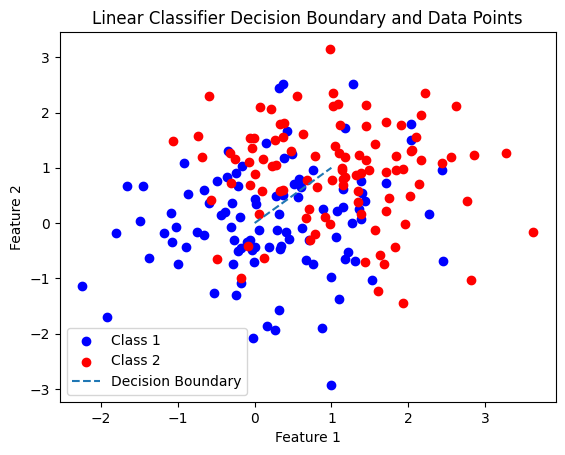

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

# 设置随机数种子以确保结果可重现
np.random.seed(10)

# 定义均值和协方差矩阵
mu1 = np.array([0.05, 0.05])
mu2 = np.array([0.95, 0.95])
sigma = np.eye(2)

# 生成两个分类的数据
data1 = np.random.multivariate_normal(mu1, sigma, 100)
data2 = np.random.multivariate_normal(mu2, sigma, 100)

# 绘制散点图
plt.figure()
plt.scatter(data1[:, 0], data1[:, 1], c='blue', label='Class 1')
plt.scatter(data2[:, 0], data2[:, 1], c='red', label='Class 2')

# 导入pdist函数
from scipy.spatial.distance import pdist

# 初始化存储数据的结构来计算准确率
accuracy = np.zeros(100)
mat1 = np.zeros((2, 2))
mat2 = np.zeros((2, 2))

# 循环以对测试点进行分类
for i in range(100):
    # 随机从均值mu1或mu2中选择一个点
    if np.random.rand() > 0.5:
        myMean = mu1
        realClass = 1
    else:
        myMean = mu2
        realClass = 2
        
    # 定义测试点
    myPoint = np.random.multivariate_normal(myMean, sigma, 1)[0]

    # 计算到mu1和mu2的距离
    mat1[0, :] = myPoint
    mat1[1, :] = mu1
    mat2[0, :] = myPoint
    mat2[1, :] = mu2
    dist1 = pdist(mat1)
    dist2 = pdist(mat2)
    
    # 判断最近的类
    if dist1 < dist2:
        predictedClass = 1
    else:
        predictedClass = 2

    # 判断预测是否正确
    if predictedClass == realClass:
        accuracy[i] = 1

# 计算平均准确率
meanAcc = np.sum(accuracy) / 100
print(f"分类准确率: {meanAcc*100:.2f}%")

# 添加决策边界代码
x_values = np.linspace(0, 1, 100)
y_values = x_values
plt.plot(x_values, y_values, label='Decision Boundary', linestyle='--')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Linear Classifier Decision Boundary and Data Points')
plt.show()